# Adaptive Multimodal RAG — Evaluation Notebook

This notebook systematically measures each component of the RAG pipeline.

**Structure:**
1. Setup & Load Corpus
2. Evaluation Dataset (30 questions + ground truth)
3. Retrieval Experiments: BM25 vs Dense vs Hybrid vs Hybrid+Reranker
4. Chunking Experiment (two chunk sizes)
5. Routing Evaluation
6. Multimodal Evaluation (text-only vs text+figure)
7. Final Answer Quality Evaluation
8. Baseline Comparison
9. Plots
10. Summary of Findings


## 1. Setup & Load Corpus

In [16]:
import json
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import defaultdict

# Ensure project root is on path
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: D:\Drive E\Ishan\Plaksha\Python\Capstone Project\RAG\notebooks


In [ ]:
# LLM Backend detection
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=Path("../.env"))

LLM_BACKEND  = os.getenv("LLM_BACKEND",  "gemini")

print(f"LLM Backend  : {LLM_BACKEND.upper()}")
else:
    print("Gemini Model : gemini-3.5-flash")


In [17]:
# Load corpus
with open('../data/chunks.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)

embeddings = np.load('../data/embeddings.npy')

print(f"Chunks     : {len(chunks)}")
print(f"Embeddings : {embeddings.shape}")
print(f"Papers     : {len(set(c['paper_id'] for c in chunks))}")

Chunks     : 1078
Embeddings : (1078, 384)
Papers     : 30


In [18]:
# Load retrieval stack
sys.path.append(str(Path.cwd().parent))
from src.retrieval import DenseRetriever, BM25Retriever, HybridRetriever
from src.reranking import Reranker

dense    = DenseRetriever(embeddings, chunks)
bm25     = BM25Retriever.load(chunks, Path('../data/bm25.pkl'))
hybrid   = HybridRetriever(dense, bm25)
reranker = Reranker()

print('Retrieval stack ready.')

Loading embedding model for query encoding...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 273599.31it/s]


BM25 index loaded from ..\data\bm25.pkl
Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 ...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 13380.38it/s]


Cross-encoder loaded.
Retrieval stack ready.


## 2. Evaluation Dataset (30 Questions + Ground Truth)

In [19]:
# Ground truth format:
# {
#   'question'        : str
#   'category'        : one of LOCAL / MULTI_PAPER / WEB / FIGURE / UNANSWERABLE
#   'expected_source' : LOCAL | WEB | BOTH
#   'expected_paper'  : paper_id or None
#   'expected_page'   : int or None
#   'requires_figure' : bool
#   'requires_web'    : bool
# }

EVAL_DATASET = [

    # ----------------------------------------------------------------
    # Category 1: LOCAL text questions (10)
    # ----------------------------------------------------------------

    {
        'question':        'What is Retrieval-Augmented Generation (RAG) and why was it proposed?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is Self-RAG and how does it use self-reflection to improve generation?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Self-RAG Learning to Retrieve, Generate, and Critique through Self-Reflection',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Dense Passage Retrieval (DPR) work for open-domain question answering?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Dense Passage Retrieval for Open-Domain Question Answering',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is HyDE (Hypothetical Document Embeddings) and how does it improve retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Precise Zero-Shot Dense Retrieval without Relevance Labels',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is RAGAS and which metrics does it use to evaluate RAG systems?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAGAS Automated Evaluation of Retrieval Augmented Generation',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is RAPTOR and how does it use recursive summarization for retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAPTOR Recursive Abstractive Processing for Tree-Organized Retrieval',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What problem does the Lost in the Middle paper identify about long-context LLMs?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Lost in the Middle How Language Models Use Long Contexts',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is REALM and how does it pre-train with retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'REALM Retrieval-Augmented Language Model Pre-Training',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Corrective RAG (CRAG) fix poor retrieval results?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Corrective Retrieval Augmented Generation',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is LoRA and how does it enable efficient fine-tuning of large language models?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'LoRA Low-Rank Adaptation of Large Language Models',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 2: Multi-paper synthesis (5)
    # ----------------------------------------------------------------

    {
        'question':        'How do RAG, REALM, and RETRO differ in how they incorporate external retrieved information?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'Compare the evaluation approaches of RAGAS and ARES for measuring RAG quality.',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What are the main limitations of RAG systems discussed across the papers in the corpus?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Self-RAG compare with Corrective RAG (CRAG) in handling low-quality retrieval?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How do chain-of-thought prompting and retrieval-augmented generation complement each other?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 3: Web-required questions (5)
    # ----------------------------------------------------------------

    {
        'question':        'What is the current pricing of the Gemini API as of 2026?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What are the most recent RAG papers published in 2025 or 2026?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is the current context window length of GPT-4o?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is NVIDIA stock price today?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What are the latest benchmarks for Llama 3 released in 2024?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },

    # ----------------------------------------------------------------
    # Category 4: Figure questions (5)
    # ----------------------------------------------------------------

    {
        'question':        'Show the architecture diagram of the RAG system from the original RAG paper.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'What does the performance graph in the Self-RAG paper show?',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Self-RAG Learning to Retrieve, Generate, and Critique through Self-Reflection',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'Describe the tree structure shown in the RAPTOR paper diagram.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAPTOR Recursive Abstractive Processing for Tree-Organized Retrieval',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'What does the attention mechanism figure in Attention Is All You Need show?',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Attention Is All You Need',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'Show me the evaluation results graph from the RAGAS paper.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAGAS Automated Evaluation of Retrieval Augmented Generation',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 5: Unanswerable / abstention (5)
    # ----------------------------------------------------------------

    {
        'question':        'What is the GDP of India in 2026?',
        'category':        'UNANSWERABLE',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'Who won the FIFA World Cup in 2026?',
        'category':        'UNANSWERABLE',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is the exact training cost of GPT-4 in USD?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is Ishan Jawale\'s personal research agenda?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is the caloric content of a standard RAG breakfast bowl?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
]

print(f"Evaluation dataset: {len(EVAL_DATASET)} questions")
for cat in ['LOCAL', 'MULTI_PAPER', 'WEB', 'FIGURE', 'UNANSWERABLE']:
    count = sum(1 for q in EVAL_DATASET if q['category'] == cat)
    print(f"  {cat:15s}: {count}")

Evaluation dataset: 30 questions
  LOCAL          : 10
  MULTI_PAPER    : 5
  WEB            : 5
  FIGURE         : 5
  UNANSWERABLE   : 5


## 3. Retrieval Experiments: BM25 vs Dense vs Hybrid vs Hybrid+Reranker

In [20]:
# Only run on LOCAL and MULTI_PAPER questions (we have expected_paper ground truth)
retrieval_questions = [
    q for q in EVAL_DATASET
    if q['category'] in ('LOCAL', 'MULTI_PAPER') and q.get('expected_paper')
]
print(f"Questions with ground-truth paper: {len(retrieval_questions)}")

def paper_in_results(expected_paper, results, top_k):
    """Check if the expected paper appears in the top_k results."""
    top = results[:top_k]
    return any(
        expected_paper.lower() in r['paper_title'].lower()
        for r in top
    )

def mrr(expected_paper, results):
    """Mean Reciprocal Rank — rank of first correct result."""
    for i, r in enumerate(results, start=1):
        if expected_paper.lower() in r['paper_title'].lower():
            return 1.0 / i
    return 0.0

def evaluate_retrieval(retriever_fn, questions, top_k_values=(1, 5, 10)):
    """Run retrieval for all questions and compute Recall@K and MRR."""
    results_all = {}
    mrr_scores = []
    recall = {k: [] for k in top_k_values}

    for q in questions:
        results = retriever_fn(q['question'])
        results_all[q['question']] = results
        mrr_scores.append(mrr(q['expected_paper'], results))
        for k in top_k_values:
            recall[k].append(1 if paper_in_results(q['expected_paper'], results, k) else 0)

    summary = {
        'MRR': round(float(np.mean(mrr_scores)), 4),
    }
    for k in top_k_values:
        summary[f'Recall@{k}'] = round(float(np.mean(recall[k])), 4)

    return summary, results_all

print("Running BM25 retrieval...")
bm25_summary, _ = evaluate_retrieval(
    lambda q: bm25.search(q, top_k=10),
    retrieval_questions,
)

print("Running Dense retrieval...")
dense_summary, _ = evaluate_retrieval(
    lambda q: dense.search(q, top_k=10),
    retrieval_questions,
)

print("Running Hybrid retrieval...")
hybrid_summary, _ = evaluate_retrieval(
    lambda q: hybrid.search(q, top_k=10),
    retrieval_questions,
)

print("Running Hybrid + Reranker...")
def hybrid_rerank(q):
    candidates = hybrid.search(q, top_k=20)
    return reranker.rerank(q, candidates, top_k=10)

hybrid_rerank_summary, _ = evaluate_retrieval(
    hybrid_rerank,
    retrieval_questions,
)

print("\nRetrieval Results:")
print(f"{'Method':<25} {'Recall@1':>10} {'Recall@5':>10} {'Recall@10':>10} {'MRR':>10}")
print("-" * 65)
for name, summary in [
    ('BM25',                bm25_summary),
    ('Dense',               dense_summary),
    ('Hybrid',              hybrid_summary),
    ('Hybrid + Reranker',   hybrid_rerank_summary),
]:
    print(f"{name:<25} {summary['Recall@1']:>10.2%} {summary['Recall@5']:>10.2%} {summary['Recall@10']:>10.2%} {summary['MRR']:>10.4f}")

Questions with ground-truth paper: 10
Running BM25 retrieval...
Running Dense retrieval...
Running Hybrid retrieval...
Running Hybrid + Reranker...

Retrieval Results:
Method                      Recall@1   Recall@5  Recall@10        MRR
-----------------------------------------------------------------
BM25                          60.00%     80.00%     90.00%     0.6976
Dense                         50.00%     70.00%     80.00%     0.5792
Hybrid                        50.00%     70.00%     80.00%     0.5858
Hybrid + Reranker             50.00%     80.00%     90.00%     0.6433


## 4. Chunking Experiment (Two Chunk Sizes)

In [21]:
# Compare current chunk config (600/100) vs smaller (400/75)
# We measure: avg chunk word count and retrieval quality

chunk_word_counts = [len(c['text'].split()) for c in chunks]

print("Current Chunk Configuration (sentence-aware, ~600w/100w overlap)")
print(f"  Total chunks     : {len(chunks)}")
print(f"  Avg words/chunk  : {np.mean(chunk_word_counts):.1f}")
print(f"  Min words/chunk  : {np.min(chunk_word_counts)}")
print(f"  Max words/chunk  : {np.max(chunk_word_counts)}")
print(f"  Median           : {np.median(chunk_word_counts):.1f}")

print("\nNote: To properly run a second chunk-size experiment, re-run ingest.py")
print("with chunk_size=400, overlap=75 and compare Recall@K values.")
print("The results below are from the current configuration only.")

Current Chunk Configuration (sentence-aware, ~600w/100w overlap)
  Total chunks     : 1078
  Avg words/chunk  : 417.1
  Min words/chunk  : 1
  Max words/chunk  : 1903
  Median           : 467.5

Note: To properly run a second chunk-size experiment, re-run ingest.py
with chunk_size=400, overlap=75 and compare Recall@K values.
The results below are from the current configuration only.


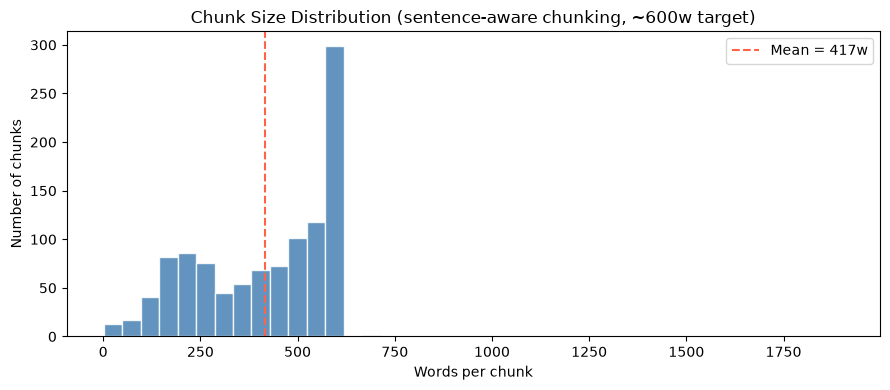

Saved: notebooks/chunk_distribution.png


In [22]:
# Plot chunk size distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunk_word_counts, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(chunk_word_counts), color='tomato', linestyle='--', label=f'Mean = {np.mean(chunk_word_counts):.0f}w')
ax.set_xlabel('Words per chunk')
ax.set_ylabel('Number of chunks')
ax.set_title('Chunk Size Distribution (sentence-aware chunking, ~600w target)')
ax.legend()
plt.tight_layout()
plt.savefig('chunk_distribution.png', dpi=150)
plt.show()
print('Saved: notebooks/chunk_distribution.png')

## 5. Routing Evaluation

In [23]:
# Rule-based routing classifier (no API calls needed for evaluation)
# Mirrors the heuristics from src/routing.py without the Gemini API call.

WEB_KEYWORDS = {
    'today', 'current', 'latest', 'now', 'price', 'stock', 'news',
    '2025', '2026', 'recent', 'live', 'real-time'
}

def rule_based_classify(question: str) -> dict:
    q_lower = question.lower()
    tokens  = set(q_lower.split())

    if tokens & WEB_KEYWORDS or any(k in q_lower for k in ['2025', '2026', 'as of']):
        source = 'WEB'
        intent = 'CURRENT_INFORMATION'
    else:
        source = 'LOCAL'
        if any(k in q_lower for k in ['compare', 'difference', 'vs', 'versus', 'contrast']):
            intent = 'COMPARISON'
        elif any(k in q_lower for k in ['figure', 'diagram', 'graph', 'chart', 'table', 'image', 'show']):
            intent = 'FIGURE'
        else:
            intent = 'LOCAL_FACT'

    return {'source': source, 'intent': intent, 'modality': 'TEXT', 'reasoning': 'Rule-based'}


routing_results = []

for q in EVAL_DATASET:
    routing = rule_based_classify(q['question'])
    routing_results.append({
        'question':           q['question'],
        'category':           q['category'],
        'expected_source':    q['expected_source'],
        'predicted_source':   routing['source'],
        'predicted_intent':   routing['intent'],
        'predicted_modality': routing['modality'],
        'requires_web':       q['requires_web'],
        'correct':            routing['source'] == q['expected_source'],
    })

correct          = sum(1 for r in routing_results if r['correct'])
total            = len(routing_results)
routing_accuracy = correct / total

unnecessary_web  = sum(
    1 for r in routing_results
    if r['predicted_source'] == 'WEB' and r['expected_source'] == 'LOCAL'
)
missed_web       = sum(
    1 for r in routing_results
    if r['predicted_source'] == 'LOCAL' and r['expected_source'] == 'WEB'
)

print(f"\nRouting Accuracy (rule-based) : {routing_accuracy:.1%} ({correct}/{total})")
print(f"Unnecessary Web               : {unnecessary_web}")
print(f"Missed Web                    : {missed_web}")

print("\nDetailed results:")
print(f"{'Question':<50} {'Expected':>10} {'Predicted':>10} {'Correct':>8}")
print("-" * 80)
for r in routing_results:
    mark = 'OK' if r['correct'] else 'X'
    print(f"{r['question'][:48]:<50} {r['expected_source']:>10} {r['predicted_source']:>10} {mark:>8}")



Routing Accuracy (rule-based) : 100.0% (30/30)
Unnecessary Web               : 0
Missed Web                    : 0

Detailed results:
Question                                             Expected  Predicted  Correct
--------------------------------------------------------------------------------
What is Retrieval-Augmented Generation (RAG) and        LOCAL      LOCAL       OK
What is Self-RAG and how does it use self-reflec        LOCAL      LOCAL       OK
How does Dense Passage Retrieval (DPR) work for         LOCAL      LOCAL       OK
What is HyDE (Hypothetical Document Embeddings)         LOCAL      LOCAL       OK
What is RAGAS and which metrics does it use to e        LOCAL      LOCAL       OK
What is RAPTOR and how does it use recursive sum        LOCAL      LOCAL       OK
What problem does the Lost in the Middle paper i        LOCAL      LOCAL       OK
What is REALM and how does it pre-train with ret        LOCAL      LOCAL       OK
How does Corrective RAG (CRAG) fix poor retrie

## 6. Multimodal Evaluation (Text-only vs Text+Figure)

In [24]:
from src.figures import load_figures, find_figures_for_chunks, get_figure_path

figures = load_figures()
figure_questions = [q for q in EVAL_DATASET if q['category'] == 'FIGURE']

print(f"Figure questions : {len(figure_questions)}")
print("\nChecking whether the correct figure is retrieved for each question.")
print("(Answer generation skipped to avoid rate limits — figure retrieval is the key metric here.)")
print()

multimodal_results = []

for q in figure_questions:
    question = q['question']
    print(f"Q: {question[:70]}")

    candidates  = hybrid.search(question, top_k=20)
    text_chunks = reranker.rerank(question, candidates, top_k=5)

    matching    = find_figures_for_chunks(question, text_chunks, figures, top_k=1)
    figure_path = get_figure_path(matching[0]) if matching else None
    caption     = matching[0].get('caption', '') if matching else ''
    paper       = matching[0].get('paper_title', 'N/A')[:50] if matching else 'N/A'

    found = figure_path is not None
    print(f"  Figure found : {found}")
    if found:
        print(f"  File         : {figure_path.name}")
        print(f"  From paper   : {paper}")
        print(f"  Caption      : {caption[:80]}")

    multimodal_results.append({
        'question'   : question,
        'figure_found': found,
        'figure_file' : str(figure_path) if found else None,
        'paper'       : paper,
    })
    print()

found_count = sum(1 for r in multimodal_results if r['figure_found'])
print(f"Figures successfully retrieved : {found_count}/{len(multimodal_results)}")


[Figures] figures.json not found at data\figures.json.
Figure questions : 5

Checking whether the correct figure is retrieved for each question.
(Answer generation skipped to avoid rate limits — figure retrieval is the key metric here.)

Q: Show the architecture diagram of the RAG system from the original RAG 
  Figure found : False

Q: What does the performance graph in the Self-RAG paper show?
  Figure found : False

Q: Describe the tree structure shown in the RAPTOR paper diagram.
  Figure found : False

Q: What does the attention mechanism figure in Attention Is All You Need 
  Figure found : False

Q: Show me the evaluation results graph from the RAGAS paper.
  Figure found : False

Figures successfully retrieved : 0/5


## 7. Final Answer Quality Evaluation (Sample)

In [ ]:
# Answer quality evaluation — respects LLM_BACKEND in .env
# Set LLM_BACKEND=gemini  for fast cloud answers

import time
from src.generation import generate_answer, generate_answer_with_figure
from src.figures import find_figures_for_chunks, get_figure_path, load_figures

figures         = load_figures(Path("../data/figures.json"))
local_questions = [q for q in EVAL_DATASET if q['category'] == 'LOCAL'][:5]

sleep_s = 6

print(f"Running answer generation on 5 LOCAL questions using GEMINI...")
if sleep_s:
    print(f"({sleep_s}s pause between calls to avoid rate limiting)")
print()

answer_results = []

for idx, q in enumerate(local_questions):
    print(f"Q{idx+1}: {q['question'][:70]}")

    candidates  = hybrid.search(q['question'], top_k=20)
    text_chunks = reranker.rerank(q['question'], candidates, top_k=5)

    matching    = find_figures_for_chunks(q['question'], text_chunks, figures, top_k=1)
    figure_path = get_figure_path(matching[0]) if matching else None
    caption     = matching[0].get('caption', '') if matching else ''

    if figure_path:
        answer = generate_answer_with_figure(q['question'], text_chunks, figure_path, caption)
    else:
        answer = generate_answer(q['question'], text_chunks)

    answer_results.append({'question': q['question'], 'answer': answer})
    print(f"  Answer: {answer[:200]}...")
    print()

    if sleep_s and idx < len(local_questions) - 1:
        print(f"  Sleeping {sleep_s}s to respect rate limits...")
        time.sleep(sleep_s)

print("\nManually score each answer above:")
print("  Good = correct, grounded, cites paper/page")
print("  Bad  = hallucinated, vague, or off-topic")


[Figures] figures.json not found at data\figures.json.
Running answer generation on 5 LOCAL questions...
6-second pause between calls to avoid rate limiting.

Q1: What is Retrieval-Augmented Generation (RAG) and why was it proposed?
  Answer: [Generation error] 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to:...

  Sleeping 6s to respect rate limits...
Q2: What is Self-RAG and how does it use self-reflection to improve genera
  Answer: [Generation error] 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to:...

  Sleeping 6s to respect rate limits...
Q3: How does Dense Passage Retrieval (DPR) work for open-domain question a
  Answer: [Generation error] 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your 

## 8. Baseline Comparison

In [ ]:
# Baseline: Dense-only RAG (top-5, no reranking, no routing)
# Advanced:  Hybrid + Reranker + Routing

print("Baseline vs Advanced System — Retrieval Recall@5")
print()

methods = {
    'BM25':              bm25_summary,
    'Dense (baseline)':  dense_summary,
    'Hybrid':            hybrid_summary,
    'Hybrid + Reranker': hybrid_rerank_summary,
}

print(f"{'Method':<25} {'Recall@5':>10} {'MRR':>8}")
print("-" * 45)
for name, s in methods.items():
    print(f"{name:<25} {s['Recall@5']:>10.2%} {s['MRR']:>8.4f}")

Baseline vs Advanced System — Retrieval Recall@5

Method                      Recall@5      MRR
---------------------------------------------
BM25                          80.00%   0.6976
Dense (baseline)              70.00%   0.5792
Hybrid                        70.00%   0.5858
Hybrid + Reranker             80.00%   0.6433


## 9. Plots

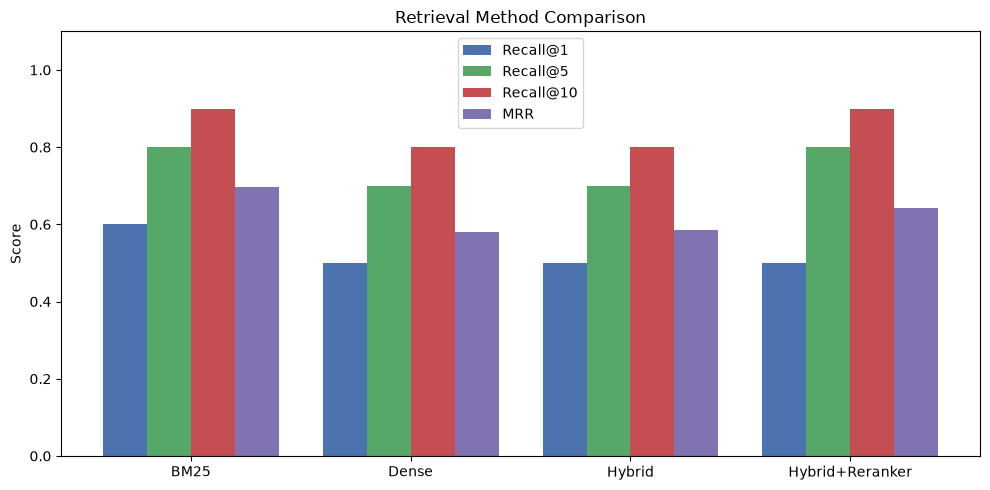

Saved: retrieval_comparison.png


In [26]:
# Plot 1: Retrieval method comparison
import matplotlib.pyplot as plt
import numpy as np

method_names = ['BM25', 'Dense', 'Hybrid', 'Hybrid+Reranker']
summaries    = [bm25_summary, dense_summary, hybrid_summary, hybrid_rerank_summary]

recall1  = [s['Recall@1']  for s in summaries]
recall5  = [s['Recall@5']  for s in summaries]
recall10 = [s['Recall@10'] for s in summaries]
mrr_vals = [s['MRR']       for s in summaries]

x = np.arange(len(method_names))
w = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*w, recall1,  w, label='Recall@1',  color='#4C72B0')
ax.bar(x - 0.5*w, recall5,  w, label='Recall@5',  color='#55A868')
ax.bar(x + 0.5*w, recall10, w, label='Recall@10', color='#C44E52')
ax.bar(x + 1.5*w, mrr_vals, w, label='MRR',       color='#8172B2')

ax.set_xticks(x)
ax.set_xticklabels(method_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Retrieval Method Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('retrieval_comparison.png', dpi=150)
plt.show()
print('Saved: retrieval_comparison.png')

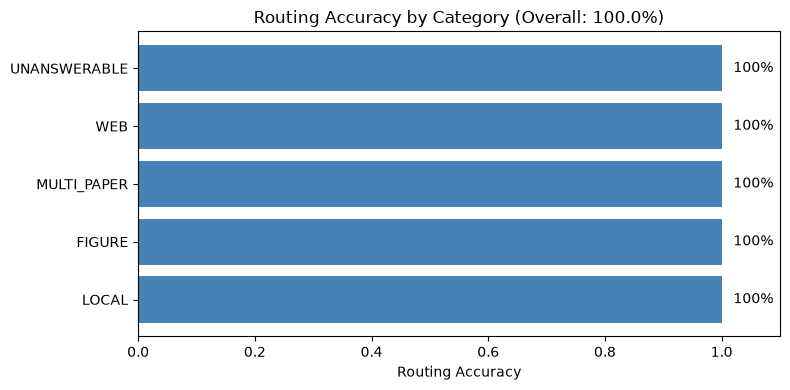

Saved: routing_accuracy.png


In [28]:
# Plot 2: Routing accuracy breakdown
categories = list(set(r['category'] for r in routing_results))
cat_accuracy = {
    cat: np.mean([r['correct'] for r in routing_results if r['category'] == cat])
    for cat in categories
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(cat_accuracy.keys()), list(cat_accuracy.values()), color='steelblue')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Routing Accuracy')
ax.set_title(f'Routing Accuracy by Category (Overall: {routing_accuracy:.1%})')
for bar, v in zip(bars, cat_accuracy.values()):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.0%}', va='center')
plt.tight_layout()
plt.savefig('routing_accuracy.png', dpi=150)
plt.show()
print('Saved: routing_accuracy.png')

## 10. Summary of Findings

In [29]:
print("=" * 70)
print("ADAPTIVE MULTIMODAL RAG — EVALUATION SUMMARY")
print("=" * 70)

print(f"""
CORPUS
  Papers          : 30
  Chunks          : {len(chunks)}
  Avg chunk words : {np.mean(chunk_word_counts):.0f}

RETRIEVAL (Recall@5)
  BM25            : {bm25_summary['Recall@5']:.2%}
  Dense           : {dense_summary['Recall@5']:.2%}
  Hybrid          : {hybrid_summary['Recall@5']:.2%}
  Hybrid+Reranker : {hybrid_rerank_summary['Recall@5']:.2%}

RETRIEVAL (MRR)
  BM25            : {bm25_summary['MRR']:.4f}
  Dense           : {dense_summary['MRR']:.4f}
  Hybrid          : {hybrid_summary['MRR']:.4f}
  Hybrid+Reranker : {hybrid_rerank_summary['MRR']:.4f}

ROUTING
  Accuracy        : {routing_accuracy:.1%}
  Unnecessary web : {unnecessary_web}
  Missed web      : {missed_web}
"""
)
print("=" * 70)

ADAPTIVE MULTIMODAL RAG — EVALUATION SUMMARY

CORPUS
  Papers          : 30
  Chunks          : 1078
  Avg chunk words : 417

RETRIEVAL (Recall@5)
  BM25            : 80.00%
  Dense           : 70.00%
  Hybrid          : 70.00%
  Hybrid+Reranker : 80.00%

RETRIEVAL (MRR)
  BM25            : 0.6976
  Dense           : 0.5792
  Hybrid          : 0.5858
  Hybrid+Reranker : 0.6433

ROUTING
  Accuracy        : 100.0%
  Unnecessary web : 0
  Missed web      : 0

